# Stereo Vision

The input is two images, left and right, and the goal is to compute the disparity using two ways: **Block Matching** and **Dynamic Programming**. 

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass

## Block Matching
- This is done by matching each pixel in the left image to a pixel in the right image. 
- Since there is no rectification needed, the row in the left image will only be matched with its equivalent in the right image. 
- The disparity will be calculated in two ways, once using the cost as the Sum of Absolute - Differences (SAD) and another time using Sum of Squared Differences.
- This will be done for windows of size w where w = 1, 5 and 9.
- 6 maps will be produced: 2 maps for each window size, once using SAD and the other using SSD.

In [5]:
def calculate_window_cost(left_w, right_w, use_sad=True):
    if use_sad:
        return np.sum(np.abs(left_w - right_w)) # Sum of Absolute Differences
    else:
        return np.sum((left_w - right_w) ** 2) # Sum of Squared Differences

In [6]:
def compute_disparity(left_image, right_image, window_size, max_disparity, use_sad=True):
    
    height, width = left_image.shape
    
    # disparity value for each pixel
    disparity_map = np.zeros((height, width), dtype=np.uint8)
    
    # get half window size to avoid going out of bounds
    half_window = window_size // 2

    # traverse vertically
    for y in range(half_window, height - half_window): 
        # traverse horizontally
        for x in range(half_window, width - half_window):
            
            # get window from left image centered at the (x,y) current pixel of size w x w
            window_left = left_image[y - half_window : y + half_window + 1, x - half_window : x + half_window + 1]
            
            min_cost = float('inf')
            best_d = 0
            
            # get candidate disparities
            for d in range(max_disparity + 1):
                
                # don't go out of bounds
                if x - half_window - d >= 0:
                    
                    # get window from right image centered at the (x-d,y) current pixel of size w x w
                    window_right = right_image[y - half_window : y + half_window + 1, x - half_window - d : x + half_window + 1 - d]
                    
                    # the lowest window cost will give the best match from which we can get the disparity
                    cost = calculate_window_cost(window_left, window_right, use_sad)
                    
                    if cost < min_cost:
                        min_cost = cost
                        best_d = d
                        
            # save best disparity for that pixel
            disparity_map[y, x] = best_d
            
    return disparity_map

In [7]:
@dataclass
class StereoPair:
    left: np.ndarray
    right: np.ndarray
    
image_pairs = []

num_pairs = 3

for i in range(1, num_pairs + 1):
    # get images in grayscale
    left = cv2.imread(f'stereo_materials/l{i}.png', cv2.IMREAD_GRAYSCALE)
    right = cv2.imread(f'stereo_materials/r{i}.png', cv2.IMREAD_GRAYSCALE)

    # cast to int32 to prevent overflow during SSD calculations
    left = left.astype(np.int32)
    right = right.astype(np.int32)

    image_pairs.append(StereoPair(left=left, right=right))

Processing Image Pair 1.
  Calculating SAD for window size 1.
  Calculating SSD for window size 1.
  Calculating SAD for window size 5.
  Calculating SSD for window size 5.
  Calculating SAD for window size 9.
  Calculating SSD for window size 9.


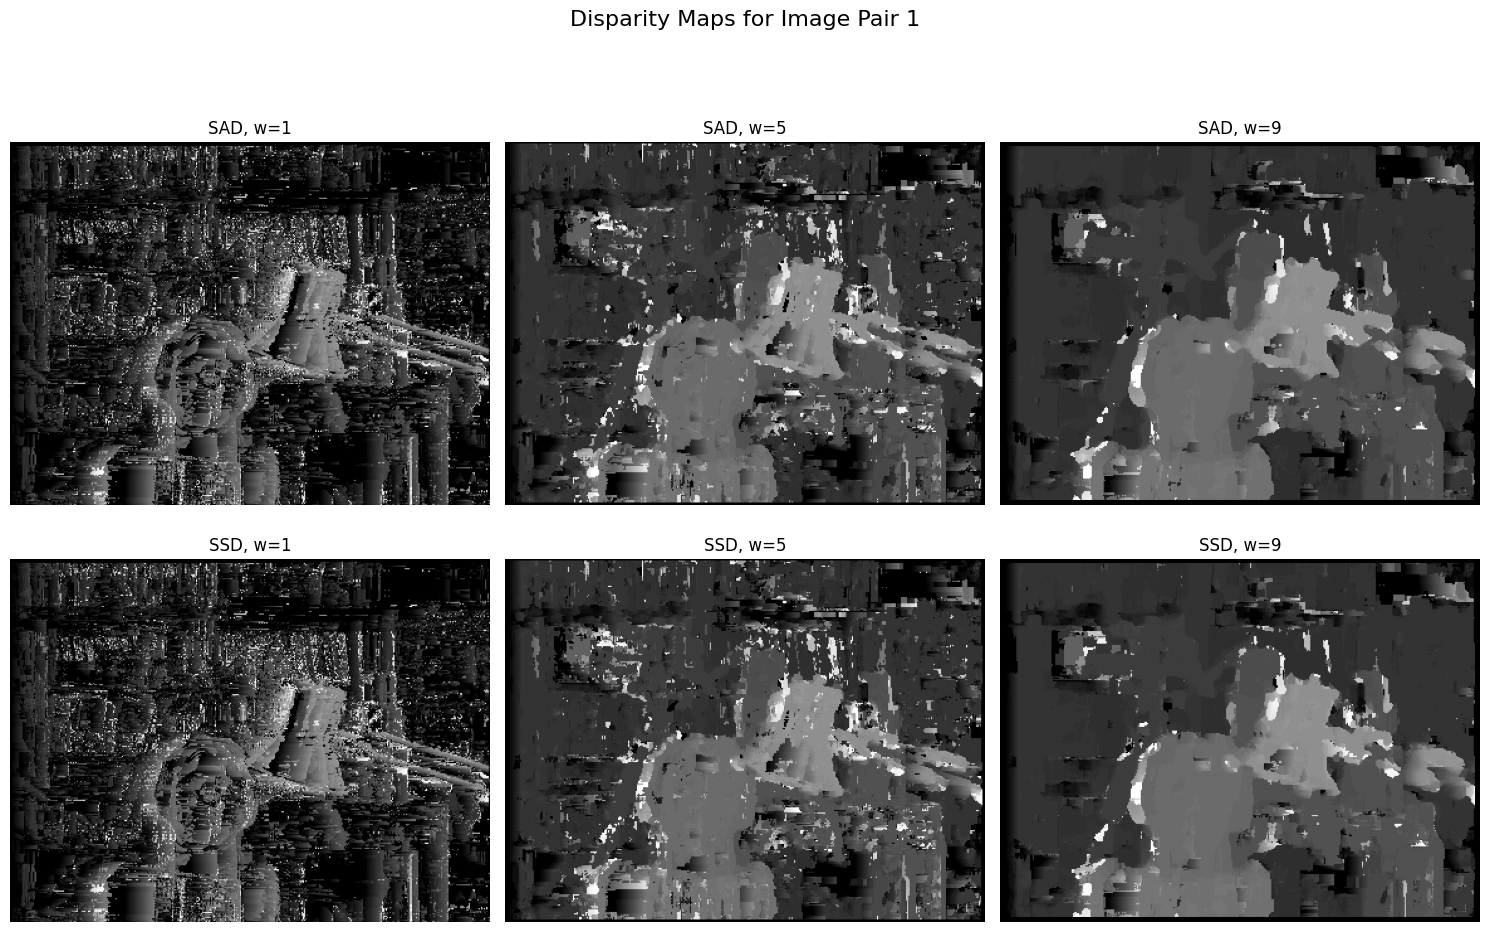

Processing Image Pair 2.
  Calculating SAD for window size 1.
  Calculating SSD for window size 1.
  Calculating SAD for window size 5.
  Calculating SSD for window size 5.
  Calculating SAD for window size 9.
  Calculating SSD for window size 9.


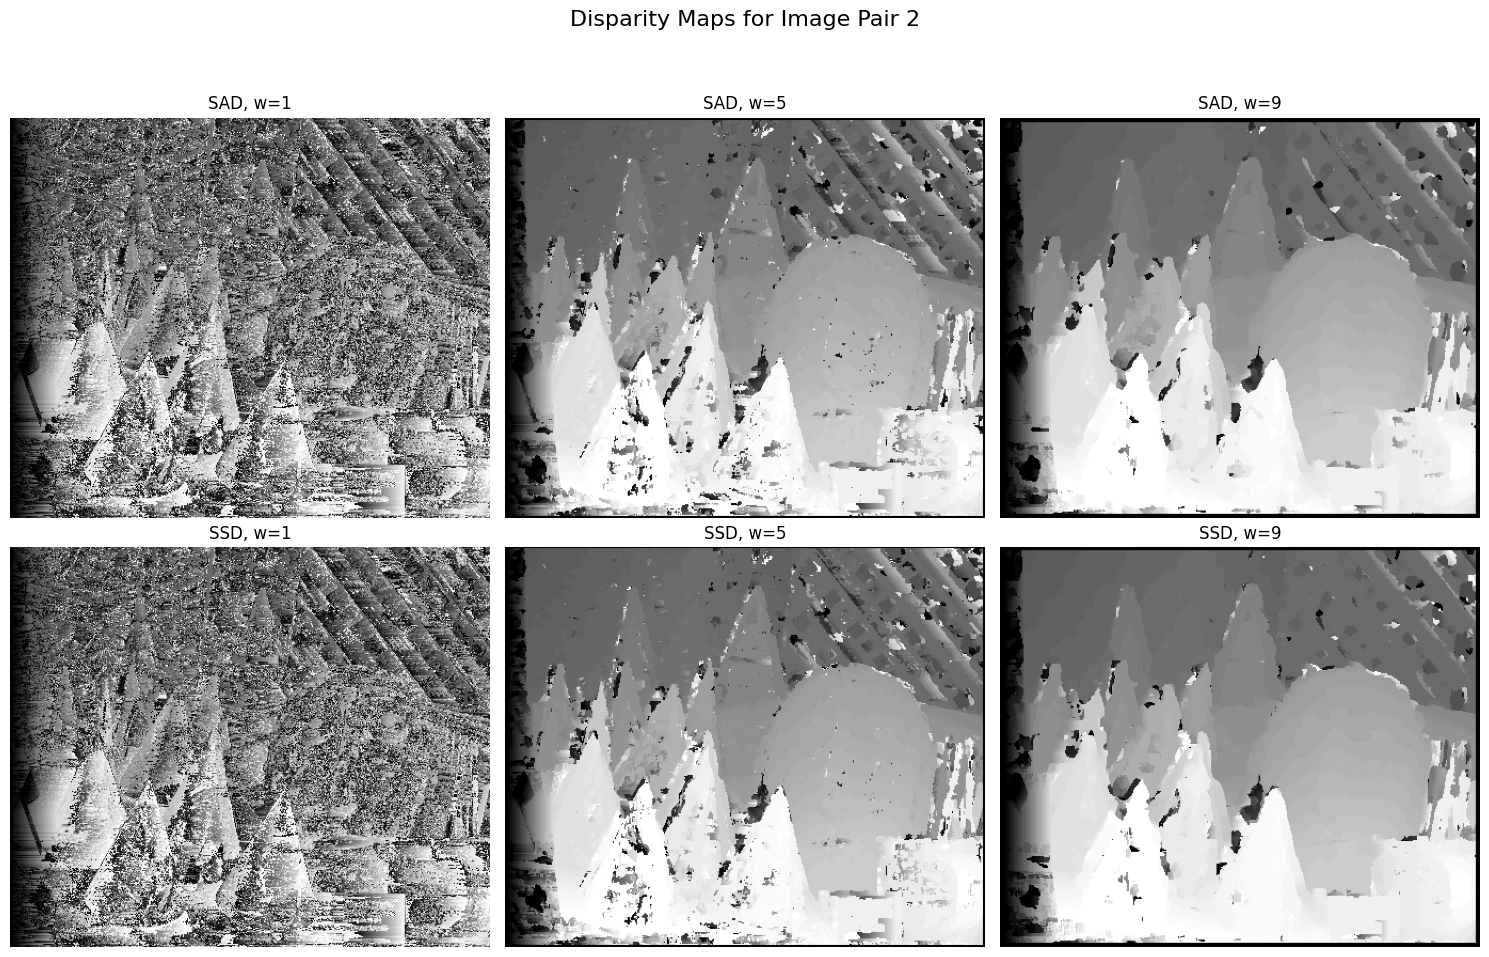

Processing Image Pair 3.
  Calculating SAD for window size 1.
  Calculating SSD for window size 1.
  Calculating SAD for window size 5.
  Calculating SSD for window size 5.
  Calculating SAD for window size 9.
  Calculating SSD for window size 9.


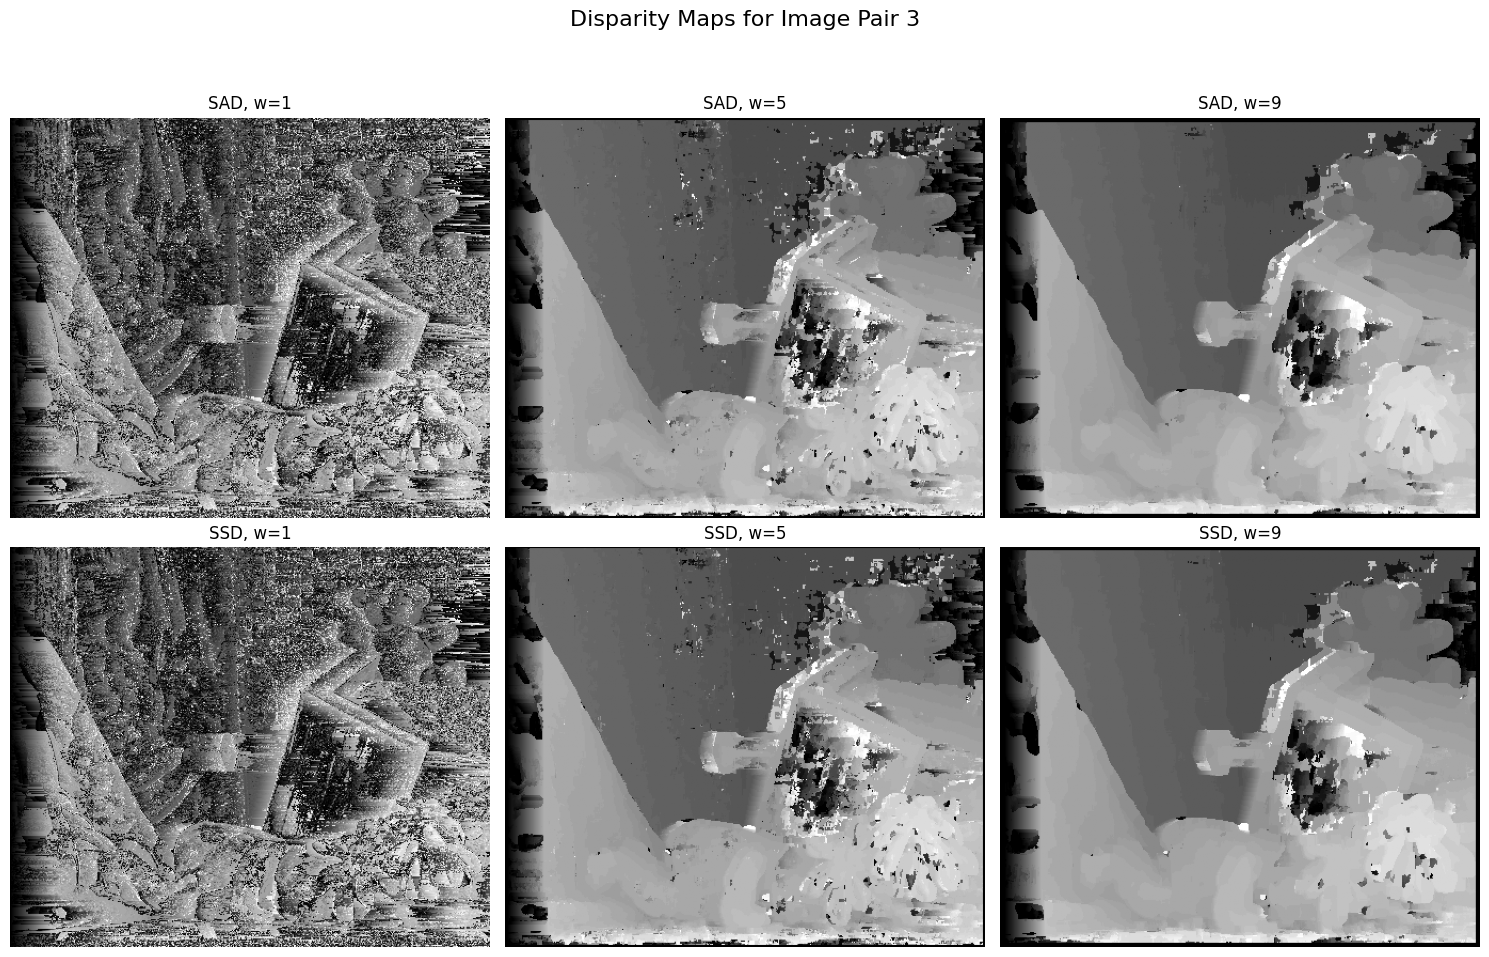

In [8]:
window_sizes = [1, 5, 9]
max_disp = 50

# enumerate returns index and value of each item in the list
for pair_index, pair in enumerate(image_pairs):
    print(f"Processing Image Pair {pair_index + 1}.")
    
    # 2x3 grid for the 6 required maps
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Disparity Maps for Image Pair {pair_index + 1}', fontsize=16)
    
    for col, w in enumerate(window_sizes):
        # compute disparity using SAD and plot 
        print(f"  Calculating SAD for window size {w}.")
        sad_map = compute_disparity(pair.left, pair.right, window_size=w, max_disparity=max_disp, use_sad=True)
        
        axes[0, col].imshow(sad_map, cmap='gray')
        axes[0, col].set_title(f'SAD, w={w}')
        axes[0, col].axis('off')

        # compute disparity using SSD and plot 
        print(f"  Calculating SSD for window size {w}.")
        ssd_map = compute_disparity(pair.left, pair.right, window_size=w, max_disparity=max_disp, use_sad=False)
        
        axes[1, col].imshow(ssd_map, cmap='gray')
        axes[1, col].set_title(f'SSD, w={w}')
        axes[1, col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()